# Notebook 2: Link Discharge Notes and Radiology Reports to Admissions

## Objective
Link both discharge summaries and radiology reports (focusing on chest X-rays) to labeled admissions from Notebook 1. Filter to admissions that have BOTH note types to enable multimodal analysis.

## Input Data
- `labeled_admissions_30day_readmission.csv` (518,349 admissions from Notebook 1)
- `discharge.csv` - Discharge summaries from MIMIC-IV-Note (331,793 notes)
- `radiology.csv` - Radiology reports from MIMIC-IV-Note (2.3M reports)

## Process
Explore radiology data structure, identify chest X-ray reports (561,837 CXR reports across 180,077 admissions), link both discharge and radiology notes to labeled admissions, filter to admissions with both note types, verify temporal consistency (reports before discharge), and analyze final cohort characteristics.

## Output
**File:** `labeled_admissions_with_discharge_and_radiology.csv`
- **Location:** `/content/drive/MyDrive/MIDS/w266/Final Project/output/`
- **Size:** 1,665 MB
- **Rows:** 140,685 admissions (27.1% of original 518K)
- **Columns:** 18 features including both discharge and radiology text

**Cohort Characteristics:**
- Admissions with discharge notes: 311,459 (60.1% coverage)
- Admissions with chest X-rays: 180,077
- Admissions with both note types: 140,685 (final cohort)
- Readmission rate: 22.06% (slightly higher than original 19.58%)
- Label distribution: 109,644 not readmitted, 31,041 readmitted

**Text Statistics:**
- Average discharge note: 11,622 characters (~2,906 tokens)
- Average radiology report: 584 characters (~146 tokens)
- Average combined length: 12,206 characters (~3,051 tokens)
- Notes exceeding 8192 token limit: 354 (0.3%) - minimal truncation needed

**Quality Checks:**
- 99.9% of radiology reports occur before discharge (168 post-discharge reports excluded)
- All admissions have complete data (no missing notes)
- Readmission rate remains balanced (22% positive class)

## Key Findings
The chest X-ray filter creates a clinically focused cohort (27% of original admissions) with slightly higher readmission risk (22% vs 20%), suggesting CXR patients may be more acutely ill. BioClinical-ModernBERT's 8192 token context window accommodates 99.7% of combined notes without truncation.

## Next Step
Notebook 4B will encode both discharge and radiology notes with BioClinical-ModernBERT (no chunking required).

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

print("Libraries imported")

Libraries imported


In [4]:
DATA_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/data')
OUTPUT_DIR = Path('/content/drive/MyDrive/MIDS/w266/Final Project/output')

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory: /content/drive/MyDrive/MIDS/w266/Final Project/data
Output directory: /content/drive/MyDrive/MIDS/w266/Final Project/output


In [5]:
# Load labeled admissions from Notebook 1
print("Loading labeled admissions from Notebook 1...")
admissions_df = pd.read_csv(OUTPUT_DIR / 'labeled_admissions_30day_readmission.csv')

print(f"Total labeled admissions: {len(admissions_df):,}")
print(f"\nColumns: {admissions_df.columns.tolist()}")
print(f"\nReadmission distribution:")
print(admissions_df['readmitted_30day'].value_counts())
print(f"\nReadmission rate: {admissions_df['readmitted_30day'].mean()*100:.2f}%")

Loading labeled admissions from Notebook 1...
Total labeled admissions: 518,349

Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'los_days', 'readmitted_30day', 'days_to_readmission', 'readmission_hadm_id']

Readmission distribution:
readmitted_30day
0    416831
1    101518
Name: count, dtype: int64

Readmission rate: 19.58%


In [6]:
# Load discharge summaries
print("\nLoading discharge summaries...")
discharge_df = pd.read_csv(DATA_DIR / 'discharge.csv')

print(f"Total discharge notes: {len(discharge_df):,}")
print(f"\nColumns: {discharge_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(discharge_df.head(3))


Loading discharge summaries...
Total discharge notes: 331,793

Columns: ['note_id', 'subject_id', 'hadm_id', 'note_type', 'note_seq', 'charttime', 'storetime', 'text']

First few rows:
          note_id  subject_id   hadm_id note_type  note_seq  \
0  10000032-DS-21    10000032  22595853        DS        21   
1  10000032-DS-22    10000032  22841357        DS        22   
2  10000032-DS-23    10000032  29079034        DS        23   

             charttime            storetime  \
0  2180-05-07 00:00:00  2180-05-09 15:26:00   
1  2180-06-27 00:00:00  2180-07-01 10:15:00   
2  2180-07-25 00:00:00  2180-07-25 21:42:00   

                                                text  
0   \nName:  ___                     Unit No:   _...  
1   \nName:  ___                     Unit No:   _...  
2   \nName:  ___                     Unit No:   _...  


In [7]:
# First, let's see what radiology files we have and understand their structure
print("\nExploring radiology data files...")
print("="*60)

# Check file sizes
radiology_file = DATA_DIR / 'radiology.csv'
radiology_detail_file = DATA_DIR / 'radiology_detail.csv'

if radiology_file.exists():
    size_mb = radiology_file.stat().st_size / (1024 * 1024)
    print(f"\nradiology.csv exists: {size_mb:.1f} MB")
else:
    print("\nradiology.csv NOT FOUND")

if radiology_detail_file.exists():
    size_mb = radiology_detail_file.stat().st_size / (1024 * 1024)
    print(f"radiology_detail.csv exists: {size_mb:.1f} MB")
else:
    print("\nradiology_detail.csv NOT FOUND")


Exploring radiology data files...

radiology.csv exists: 2738.2 MB
radiology_detail.csv exists: 292.3 MB


In [8]:
# Load radiology.csv
print("\nLoading radiology.csv...")
radiology_df = pd.read_csv(DATA_DIR / 'radiology.csv')

print(f"Total radiology reports: {len(radiology_df):,}")
print(f"\nColumns: {radiology_df.columns.tolist()}")
print(f"\nData types:")
print(radiology_df.dtypes)
print(f"\nFirst few rows:")
print(radiology_df.head(3))

print(f"\nUnique admissions with radiology reports: {radiology_df['hadm_id'].nunique():,}")
print(f"\nSample text from first report:")
if 'text' in radiology_df.columns:
    print(radiology_df['text'].iloc[0][:500])
else:
    print("No 'text' column found - checking other columns...")
    print(radiology_df.iloc[0])


Loading radiology.csv...
Total radiology reports: 2,321,355

Columns: ['note_id', 'subject_id', 'hadm_id', 'note_type', 'note_seq', 'charttime', 'storetime', 'text']

Data types:
note_id        object
subject_id      int64
hadm_id       float64
note_type      object
note_seq        int64
charttime      object
storetime      object
text           object
dtype: object

First few rows:
          note_id  subject_id     hadm_id note_type  note_seq  \
0  10000032-RR-14    10000032  22595853.0        RR        14   
1  10000032-RR-15    10000032  22595853.0        RR        15   
2  10000032-RR-16    10000032  22595853.0        RR        16   

             charttime            storetime  \
0  2180-05-06 21:19:00  2180-05-06 23:32:00   
1  2180-05-06 23:00:00  2180-05-06 23:26:00   
2  2180-05-07 09:55:00  2180-05-07 11:15:00   

                                                text  
0  EXAMINATION:  CHEST (PA AND LAT)\n\nINDICATION...  
1  EXAMINATION:  LIVER OR GALLBLADDER US (SINGLE ... 

In [9]:
# Load radiology_detail.csv
print("\nLoading radiology_detail.csv...")
radiology_detail_df = pd.read_csv(DATA_DIR / 'radiology_detail.csv')

print(f"Total radiology detail records: {len(radiology_detail_df):,}")
print(f"\nColumns: {radiology_detail_df.columns.tolist()}")
print(f"\nFirst few rows:")
print(radiology_detail_df.head(10))

print(f"\nUnique values in key columns:")
for col in radiology_detail_df.columns:
    if radiology_detail_df[col].dtype == 'object' and col != 'text':
        print(f"\n{col}: {radiology_detail_df[col].nunique()} unique values")
        print(radiology_detail_df[col].value_counts().head(10))


Loading radiology_detail.csv...
Total radiology detail records: 6,046,121

Columns: ['note_id', 'subject_id', 'field_name', 'field_value', 'field_ordinal']

First few rows:
          note_id  subject_id field_name  \
0  10000032-RR-14    10000032  exam_code   
1  10000032-RR-14    10000032  exam_name   
2  10000032-RR-15    10000032  exam_code   
3  10000032-RR-15    10000032  exam_code   
4  10000032-RR-15    10000032  exam_code   
5  10000032-RR-15    10000032  exam_name   
6  10000032-RR-15    10000032  exam_name   
7  10000032-RR-15    10000032  exam_name   
8  10000032-RR-16    10000032  exam_code   
9  10000032-RR-16    10000032  exam_name   

                               field_value  field_ordinal  
0                                      C11              1  
1                         CHEST (PA & LAT)              1  
2                                     U314              1  
3                                     U644              3  
4                                      W8

In [10]:
# Let's understand the relationship between radiology.csv and radiology_detail.csv
print("\nAnalyzing radiology data structure...")
print("="*60)

# Check if there's a note_id or similar linking column
if 'note_id' in radiology_df.columns and 'note_id' in radiology_detail_df.columns:
    print("\nBoth files have 'note_id' - they are linked!")

    # How many detail records per note?
    details_per_note = radiology_detail_df.groupby('note_id').size()
    print(f"\nDetail records per note:")
    print(f"  Mean: {details_per_note.mean():.1f}")
    print(f"  Median: {details_per_note.median():.0f}")
    print(f"  Max: {details_per_note.max()}")

    # Check what sections exist
    if 'field_name' in radiology_detail_df.columns:
        print(f"\nRadiology report sections:")
        print(radiology_detail_df['field_name'].value_counts())

# Check if radiology.csv has the full text or if we need to reconstruct from detail
if 'text' in radiology_df.columns:
    avg_length = radiology_df['text'].str.len().mean()
    print(f"\nradiology.csv has 'text' column")
    print(f"Average text length: {avg_length:.0f} characters")
else:
    print(f"\nradiology.csv does NOT have full 'text' - may need to reconstruct from detail")


Analyzing radiology data structure...

Both files have 'note_id' - they are linked!

Detail records per note:
  Mean: 2.6
  Median: 2
  Max: 271

Radiology report sections:
field_name
exam_code           2913024
exam_name           2913024
cpt_code             168603
parent_note_id        25735
addendum_note_id      25735
Name: count, dtype: int64

radiology.csv has 'text' column
Average text length: 1159 characters


In [11]:
# We need to identify chest X-rays specifically
print("\nIdentifying chest X-ray reports...")
print("="*60)

# Strategy 1: Check if there's a 'category' or 'exam_type' column
if 'category' in radiology_df.columns:
    print("\nReport categories:")
    print(radiology_df['category'].value_counts())

# Strategy 2: Search text for chest-related keywords
if 'text' in radiology_df.columns:
    # Look for chest X-ray indicators
    chest_keywords = ['chest', 'thorax', 'cxr', 'portable chest', 'ap chest']

    # Create boolean mask for chest reports
    is_chest = radiology_df['text'].str.lower().str.contains('|'.join(chest_keywords), na=False)

    print(f"\nReports containing chest keywords: {is_chest.sum():,} ({is_chest.sum()/len(radiology_df)*100:.1f}%)")

    # More specific: actual chest X-ray (not CT)
    is_cxr = (
        radiology_df['text'].str.lower().str.contains('chest', na=False) &
        ~radiology_df['text'].str.lower().str.contains('ct|computed tomography', na=False)
    )

    print(f"Chest X-rays (excluding CT): {is_cxr.sum():,} ({is_cxr.sum()/len(radiology_df)*100:.1f}%)")

# Strategy 3: Check radiology_detail if text not in main file
elif 'field_name' in radiology_detail_df.columns and 'field_value' in radiology_detail_df.columns:
    print("\nSearching radiology_detail for chest X-rays...")

    # Look in examination field
    exam_field = radiology_detail_df[radiology_detail_df['field_name'] == 'examination']
    if len(exam_field) > 0:
        print(f"\nExamination types:")
        print(exam_field['field_value'].value_counts().head(20))


Identifying chest X-ray reports...

Reports containing chest keywords: 976,361 (42.1%)
Chest X-rays (excluding CT): 196,719 (8.5%)


In [12]:
# Based on the exploration above, filter to chest X-rays
# ADJUST THIS CELL BASED ON WHAT WE FOUND IN CELL 10

print("\nFiltering to chest X-ray reports...")

# Method 1: If 'text' column exists in radiology.csv
if 'text' in radiology_df.columns:
    # Filter for chest X-rays (not CT scans)
    chest_xray_df = radiology_df[
        (radiology_df['text'].str.lower().str.contains('chest', na=False)) &
        (~radiology_df['text'].str.lower().str.contains('ct |computed tomography', na=False))
    ].copy()

    print(f"Chest X-ray reports: {len(chest_xray_df):,}")
    print(f"Unique admissions with CXR: {chest_xray_df['hadm_id'].nunique():,}")

# Method 2: If we need to reconstruct from radiology_detail
else:
    print("Need to reconstruct text from radiology_detail...")
    # We'll handle this based on what we see in the data

    # Placeholder - adjust based on actual data structure
    chest_xray_df = radiology_df.copy()  # Temporary, will refine

print(f"\nSample chest X-ray report:")
if 'text' in chest_xray_df.columns:
    print(chest_xray_df['text'].iloc[0][:1000])


Filtering to chest X-ray reports...
Chest X-ray reports: 561,837
Unique admissions with CXR: 180,077

Sample chest X-ray report:
EXAMINATION:  CHEST (PA AND LAT)

INDICATION:  History: ___ with shortness of breath

TECHNIQUE:  Chest PA and lateral

COMPARISON:  ___

FINDINGS: 

The cardiac, mediastinal and hilar contours are normal. Pulmonary vasculature
is normal.  Lungs are clear. No pleural effusion or pneumothorax is present.
Multiple clips are again seen projecting over the left breast.  Remote
left-sided rib fractures are also re- demonstrated.

IMPRESSION: 

No acute cardiopulmonary abnormality.



In [13]:
# Check if admissions have multiple chest X-ray reports
print("\nAnalyzing reports per admission...")

reports_per_admission = chest_xray_df.groupby('hadm_id').size()
print(f"Reports per admission:")
print(f"  Mean: {reports_per_admission.mean():.2f}")
print(f"  Median: {reports_per_admission.median():.0f}")
print(f"  Max: {reports_per_admission.max()}")

# Show distribution
print(f"\nDistribution:")
print(reports_per_admission.value_counts().sort_index().head(10))

# Decide on strategy for multiple reports
print(f"\n" + "="*60)
print("Strategy for multiple reports per admission:")
print("  Option 1: Keep only the last report (closest to discharge)")
print("  Option 2: Concatenate all reports")
print("  Option 3: Keep the longest report")
print("="*60)

# Let's use Option 1: Keep last report (most recent before discharge)
print("\nImplementing: Keep last report per admission...")

if 'charttime' in chest_xray_df.columns:
    # Sort by admission and chart time, keep last
    chest_xray_df = chest_xray_df.sort_values(['hadm_id', 'charttime'])
    chest_xray_df = chest_xray_df.groupby('hadm_id').last().reset_index()
elif 'chartdate' in chest_xray_df.columns:
    chest_xray_df = chest_xray_df.sort_values(['hadm_id', 'chartdate'])
    chest_xray_df = chest_xray_df.groupby('hadm_id').last().reset_index()
else:
    # If no time info, just keep first occurrence
    chest_xray_df = chest_xray_df.drop_duplicates(subset='hadm_id', keep='first')

print(f"After keeping one report per admission: {len(chest_xray_df):,} reports")
print(f"Unique admissions: {chest_xray_df['hadm_id'].nunique():,}")


Analyzing reports per admission...
Reports per admission:
  Mean: 2.22
  Median: 1
  Max: 125

Distribution:
1     117080
2      26592
3      12026
4       7070
5       4276
6       2801
7       2053
8       1473
9       1167
10       892
Name: count, dtype: int64

Strategy for multiple reports per admission:
  Option 1: Keep only the last report (closest to discharge)
  Option 2: Concatenate all reports
  Option 3: Keep the longest report

Implementing: Keep last report per admission...
After keeping one report per admission: 180,077 reports
Unique admissions: 180,077


In [14]:
# Link discharge notes to labeled admissions (same as before)
print("\nLinking discharge notes to labeled admissions...")

# Merge discharge notes with admissions
admissions_with_discharge = admissions_df.merge(
    discharge_df[['hadm_id', 'text', 'charttime', 'note_id']],
    on='hadm_id',
    how='inner'
)

# Rename discharge text column
admissions_with_discharge = admissions_with_discharge.rename(columns={
    'text': 'discharge_text',
    'charttime': 'discharge_charttime',
    'note_id': 'discharge_note_id'
})

print(f"Admissions with discharge notes: {len(admissions_with_discharge):,}")
print(f"Coverage: {len(admissions_with_discharge)/len(admissions_df)*100:.1f}%")

# Check label distribution
print(f"\nReadmission rate in discharge cohort: {admissions_with_discharge['readmitted_30day'].mean()*100:.2f}%")


Linking discharge notes to labeled admissions...
Admissions with discharge notes: 311,459
Coverage: 60.1%

Readmission rate in discharge cohort: 20.65%


In [15]:
# Now add chest X-ray reports
print("\nLinking chest X-ray reports to admissions with discharge notes...")

# Rename CXR columns to avoid conflicts
chest_xray_df = chest_xray_df.rename(columns={
    'text': 'radiology_text',
    'charttime': 'radiology_charttime',
    'note_id': 'radiology_note_id'
})

# Merge - keep only admissions that have BOTH discharge AND CXR
admissions_with_both = admissions_with_discharge.merge(
    chest_xray_df[['hadm_id', 'radiology_text', 'radiology_charttime', 'radiology_note_id']],
    on='hadm_id',
    how='inner'
)

print(f"\nAdmissions with BOTH discharge and CXR: {len(admissions_with_both):,}")
print(f"Coverage from original: {len(admissions_with_both)/len(admissions_df)*100:.1f}%")
print(f"Coverage from discharge cohort: {len(admissions_with_both)/len(admissions_with_discharge)*100:.1f}%")

# Check label distribution
print(f"\nReadmission rate in final cohort: {admissions_with_both['readmitted_30day'].mean()*100:.2f}%")
print(f"\nLabel distribution:")
print(admissions_with_both['readmitted_30day'].value_counts())


Linking chest X-ray reports to admissions with discharge notes...

Admissions with BOTH discharge and CXR: 140,853
Coverage from original: 27.2%
Coverage from discharge cohort: 45.2%

Readmission rate in final cohort: 22.12%

Label distribution:
readmitted_30day
0    109698
1     31155
Name: count, dtype: int64


In [16]:
# Analyze note lengths
print("\nAnalyzing note lengths...")
print("="*60)

# Discharge note lengths
admissions_with_both['discharge_length'] = admissions_with_both['discharge_text'].str.len()
admissions_with_both['radiology_length'] = admissions_with_both['radiology_text'].str.len()

print("\nDischarge note statistics:")
print(f"  Mean: {admissions_with_both['discharge_length'].mean():.0f} characters")
print(f"  Median: {admissions_with_both['discharge_length'].median():.0f} characters")
print(f"  Min: {admissions_with_both['discharge_length'].min():.0f} characters")
print(f"  Max: {admissions_with_both['discharge_length'].max():.0f} characters")

print("\nRadiology note statistics:")
print(f"  Mean: {admissions_with_both['radiology_length'].mean():.0f} characters")
print(f"  Median: {admissions_with_both['radiology_length'].median():.0f} characters")
print(f"  Min: {admissions_with_both['radiology_length'].min():.0f} characters")
print(f"  Max: {admissions_with_both['radiology_length'].max():.0f} characters")

# Combined length
admissions_with_both['combined_length'] = (
    admissions_with_both['discharge_length'] +
    admissions_with_both['radiology_length']
)

print("\nCombined (discharge + radiology) statistics:")
print(f"  Mean: {admissions_with_both['combined_length'].mean():.0f} characters")
print(f"  Median: {admissions_with_both['combined_length'].median():.0f} characters")
print(f"  Max: {admissions_with_both['combined_length'].max():.0f} characters")

# Check against BioClinical-ModernBERT context window
# Rough estimate: 1 token ≈ 4 characters
admissions_with_both['estimated_tokens'] = admissions_with_both['combined_length'] / 4

print(f"\nEstimated tokens (chars/4):")
print(f"  Mean: {admissions_with_both['estimated_tokens'].mean():.0f}")
print(f"  Median: {admissions_with_both['estimated_tokens'].median():.0f}")
print(f"  Max: {admissions_with_both['estimated_tokens'].max():.0f}")

# Check how many exceed 8192 token limit
exceeds_limit = (admissions_with_both['estimated_tokens'] > 8192).sum()
print(f"\nNotes exceeding 8192 token limit: {exceeds_limit:,} ({exceeds_limit/len(admissions_with_both)*100:.1f}%)")


Analyzing note lengths...

Discharge note statistics:
  Mean: 11620 characters
  Median: 10932 characters
  Min: 353 characters
  Max: 60381 characters

Radiology note statistics:
  Mean: 584 characters
  Median: 517 characters
  Min: 53 characters
  Max: 10335 characters

Combined (discharge + radiology) statistics:
  Mean: 12204 characters
  Median: 11515 characters
  Max: 61103 characters

Estimated tokens (chars/4):
  Mean: 3051
  Median: 2879
  Max: 15276

Notes exceeding 8192 token limit: 356 (0.3%)


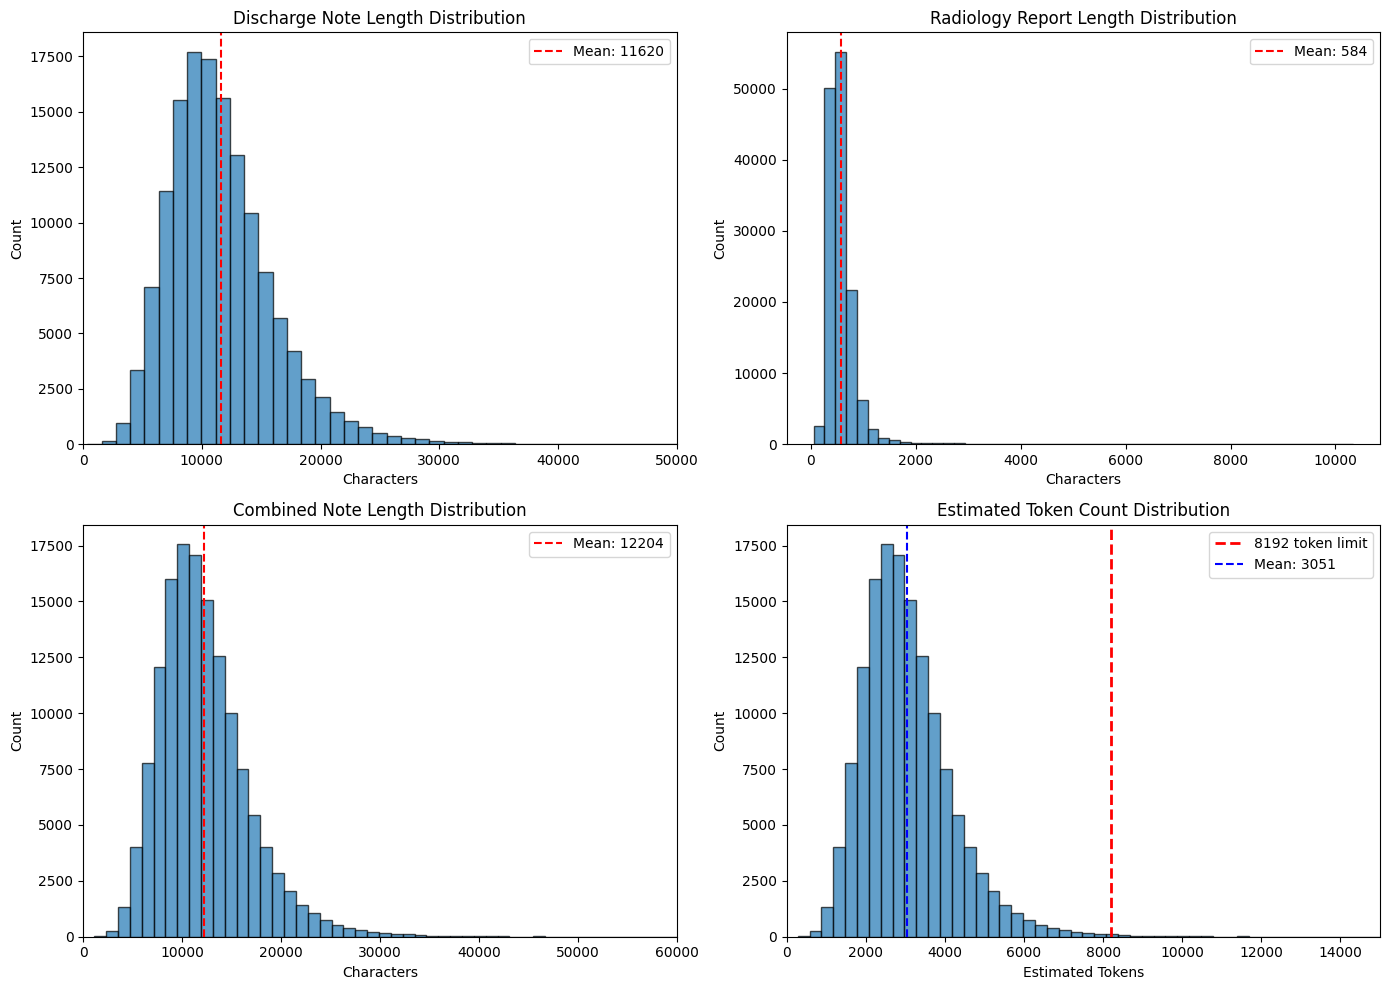

Visualization saved


In [17]:
# Plot text length distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Discharge lengths
axes[0, 0].hist(admissions_with_both['discharge_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Discharge Note Length Distribution')
axes[0, 0].axvline(admissions_with_both['discharge_length'].mean(), color='red',
                    linestyle='--', label=f"Mean: {admissions_with_both['discharge_length'].mean():.0f}")
axes[0, 0].legend()
axes[0, 0].set_xlim(0, min(50000, admissions_with_both['discharge_length'].max()))

# Radiology lengths
axes[0, 1].hist(admissions_with_both['radiology_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Characters')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Radiology Report Length Distribution')
axes[0, 1].axvline(admissions_with_both['radiology_length'].mean(), color='red',
                    linestyle='--', label=f"Mean: {admissions_with_both['radiology_length'].mean():.0f}")
axes[0, 1].legend()

# Combined lengths
axes[1, 0].hist(admissions_with_both['combined_length'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Characters')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Combined Note Length Distribution')
axes[1, 0].axvline(admissions_with_both['combined_length'].mean(), color='red',
                    linestyle='--', label=f"Mean: {admissions_with_both['combined_length'].mean():.0f}")
axes[1, 0].legend()
axes[1, 0].set_xlim(0, min(60000, admissions_with_both['combined_length'].max()))

# Estimated tokens
axes[1, 1].hist(admissions_with_both['estimated_tokens'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Estimated Tokens')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Estimated Token Count Distribution')
axes[1, 1].axvline(8192, color='red', linestyle='--', linewidth=2, label='8192 token limit')
axes[1, 1].axvline(admissions_with_both['estimated_tokens'].mean(), color='blue',
                    linestyle='--', label=f"Mean: {admissions_with_both['estimated_tokens'].mean():.0f}")
axes[1, 1].legend()
axes[1, 1].set_xlim(0, min(15000, admissions_with_both['estimated_tokens'].max()))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'note_length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved")

In [18]:
# Verify that radiology reports come before or during admission
print("\nChecking temporal consistency...")
print("="*60)

# Convert to datetime
admissions_with_both['dischtime'] = pd.to_datetime(admissions_with_both['dischtime'])
admissions_with_both['radiology_charttime'] = pd.to_datetime(admissions_with_both['radiology_charttime'])
admissions_with_both['discharge_charttime'] = pd.to_datetime(admissions_with_both['discharge_charttime'])

# Check if radiology report is before discharge
radiology_before_discharge = (
    admissions_with_both['radiology_charttime'] <= admissions_with_both['dischtime']
)

print(f"Radiology reports before/at discharge: {radiology_before_discharge.sum():,} ({radiology_before_discharge.sum()/len(admissions_with_both)*100:.1f}%)")

if not radiology_before_discharge.all():
    print(f"\nWARNING: {(~radiology_before_discharge).sum():,} radiology reports are AFTER discharge")
    print("These might be follow-up reports and should potentially be excluded")

    # Option to filter
    print("\nFiltering to reports before discharge only...")
    admissions_with_both = admissions_with_both[radiology_before_discharge].copy()
    print(f"Final cohort after filtering: {len(admissions_with_both):,}")


Checking temporal consistency...
Radiology reports before/at discharge: 140,685 (99.9%)

These might be follow-up reports and should potentially be excluded

Filtering to reports before discharge only...
Final cohort after filtering: 140,685


In [19]:
# Final summary
print("\n" + "="*60)
print("FINAL COHORT SUMMARY")
print("="*60)

print(f"\nCohort progression:")
print(f"  Original labeled admissions: {len(admissions_df):,}")
print(f"  With discharge notes: {len(admissions_with_discharge):,} ({len(admissions_with_discharge)/len(admissions_df)*100:.1f}%)")
print(f"  With chest X-rays: {180077:,}")
print(f"  With BOTH notes: {len(admissions_with_both):,} ({len(admissions_with_both)/len(admissions_df)*100:.1f}%)")

print(f"\nReadmission statistics:")
print(f"  Original rate: {admissions_df['readmitted_30day'].mean()*100:.2f}%")
print(f"  Final cohort rate: {admissions_with_both['readmitted_30day'].mean()*100:.2f}%")
print(f"\nLabel distribution:")
print(admissions_with_both['readmitted_30day'].value_counts())

print(f"\nText statistics:")
print(f"  Average discharge note: {admissions_with_both['discharge_length'].mean():.0f} chars")
print(f"  Average radiology note: {admissions_with_both['radiology_length'].mean():.0f} chars")
print(f"  Average combined: {admissions_with_both['combined_length'].mean():.0f} chars")
print(f"  Average estimated tokens: {admissions_with_both['estimated_tokens'].mean():.0f}")
print(f"  Notes exceeding 8192 tokens: {(admissions_with_both['estimated_tokens'] > 8192).sum():,} ({(admissions_with_both['estimated_tokens'] > 8192).sum()/len(admissions_with_both)*100:.1f}%)")

print(f"\nColumns in final dataset:")
print(admissions_with_both.columns.tolist())


FINAL COHORT SUMMARY

Cohort progression:
  Original labeled admissions: 518,349
  With discharge notes: 311,459 (60.1%)
  With chest X-rays: 180,077
  With BOTH notes: 140,685 (27.1%)

Readmission statistics:
  Original rate: 19.58%
  Final cohort rate: 22.06%

Label distribution:
readmitted_30day
0    109644
1     31041
Name: count, dtype: int64

Text statistics:
  Average discharge note: 11622 chars
  Average radiology note: 584 chars
  Average combined: 12206 chars
  Average estimated tokens: 3051
  Notes exceeding 8192 tokens: 354 (0.3%)

Columns in final dataset:
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'los_days', 'readmitted_30day', 'days_to_readmission', 'readmission_hadm_id', 'discharge_text', 'discharge_charttime', 'discharge_note_id', 'radiology_text', 'radiology_charttime', 'radiology_note_id', 'discharge_length', 'radiology_length', 'combined_length

In [20]:
# Save the final dataset
output_file = OUTPUT_DIR / 'labeled_admissions_with_discharge_and_radiology.csv'

# Select relevant columns
columns_to_save = [
    'hadm_id', 'subject_id',
    'admittime', 'dischtime',
    'admission_type', 'admission_location', 'discharge_location',
    'insurance', 'language', 'marital_status', 'race',
    'discharge_text', 'discharge_charttime', 'discharge_note_id',
    'radiology_text', 'radiology_charttime', 'radiology_note_id',
    'readmitted_30day'
]

# Save
admissions_with_both[columns_to_save].to_csv(output_file, index=False)

print(f"\nDataset saved to: {output_file}")
print(f"File size: {output_file.stat().st_size / (1024*1024):.2f} MB")
print(f"Rows: {len(admissions_with_both):,}")
print(f"Columns: {len(columns_to_save)}")


Dataset saved to: /content/drive/MyDrive/MIDS/w266/Final Project/output/labeled_admissions_with_discharge_and_radiology.csv
File size: 1665.25 MB
Rows: 140,685
Columns: 18


In [21]:
print("\n" + "="*60)
print("NOTEBOOK 2B COMPLETE")
print("="*60)

print(f"\nAchieved:")
print(f"  ✓ Linked discharge notes to labeled admissions")
print(f"  ✓ Identified {180077:,} admissions with chest X-rays")
print(f"  ✓ Created cohort of {len(admissions_with_both):,} admissions with BOTH note types")
print(f"  ✓ Verified temporal consistency (reports before discharge)")
print(f"  ✓ Analyzed text lengths and token estimates")

print(f"\nOutput:")
print(f"  {output_file}")

print(f"\nNext step:")
print(f"  Notebook 4B: Encode both note types with BioClinical-ModernBERT")
print(f"  - No chunking needed (8192 token context)")
print(f"  - Encode discharge and radiology separately")
print(f"  - Combine embeddings for multimodal fusion")


NOTEBOOK 2B COMPLETE

Achieved:
  ✓ Linked discharge notes to labeled admissions
  ✓ Identified 180,077 admissions with chest X-rays
  ✓ Created cohort of 140,685 admissions with BOTH note types
  ✓ Verified temporal consistency (reports before discharge)
  ✓ Analyzed text lengths and token estimates

Output:
  /content/drive/MyDrive/MIDS/w266/Final Project/output/labeled_admissions_with_discharge_and_radiology.csv

Next step:
  Notebook 4B: Encode both note types with BioClinical-ModernBERT
  - No chunking needed (8192 token context)
  - Encode discharge and radiology separately
  - Combine embeddings for multimodal fusion
